In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
print("Libraries ready ￿")

Libraries ready ￿


In [3]:
# Load both files
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')
# Check what we loaded
print("Matches rows:", matches.shape[0])
print("Matches columns:", matches.shape[1])
print("Deliveries rows:", deliveries.shape[0])
print("Deliveries columns:", deliveries.shape[1])
 #Run these in new cells to understand the data:
# See first 5 rows of matches
matches.head()
# See first 5 rows of deliveries
deliveries.head()

Matches rows: 854
Matches columns: 17
Deliveries rows: 180000
Deliveries columns: 22


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,is_wicket,dismissal_kind,player_dismissed,fielder
0,11,1,Sunrisers Hyderabad,Mumbai Indians,0,1,HH Pandya,Q de Kock,PP Chawla,0,...,0,0,0,6,0,6,0,NaN,NaN,NaN
1,11,1,Sunrisers Hyderabad,Mumbai Indians,0,2,HH Pandya,HH Pandya,PP Chawla,0,...,0,0,0,1,0,1,0,NaN,NaN,NaN
2,11,1,Sunrisers Hyderabad,Mumbai Indians,0,3,HH Pandya,MS Dhoni,PP Chawla,0,...,0,0,0,4,0,4,0,NaN,NaN,NaN
3,11,1,Sunrisers Hyderabad,Mumbai Indians,0,4,HH Pandya,KA Pollard,PP Chawla,0,...,0,0,0,4,0,4,0,NaN,NaN,NaN
4,11,1,Sunrisers Hyderabad,Mumbai Indians,0,5,HH Pandya,RG Sharma,PP Chawla,0,...,0,0,0,2,0,2,0,NaN,NaN,NaN


In [4]:
# Keep only matches that have a winner
# notna() means the winner column is not empty
# != '' means the winner column is not a blank text
matches_clean = matches[matches['winner'].notna()].copy()
matches_clean = matches_clean[matches_clean['winner'] != ''].copy()
# Check results
print("Original matches:", len(matches))
print("Matches with a winner:", len(matches_clean))
print("Seasons in data:", sorted(matches_clean['season'].unique().tolist()))

Original matches: 854
Matches with a winner: 835
Seasons in data: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


Wins per team:
winner
Rajasthan Royals               119
Chennai Super Kings            118
Sunrisers Hyderabad            111
Mumbai Indians                 107
Kolkata Knight Riders          105
Punjab Kings                    99
Royal Challengers Bangalore     83
Delhi Capitals                  80
Gujarat Titans                   7
Lucknow Super Giants             6
Name: count, dtype: int64


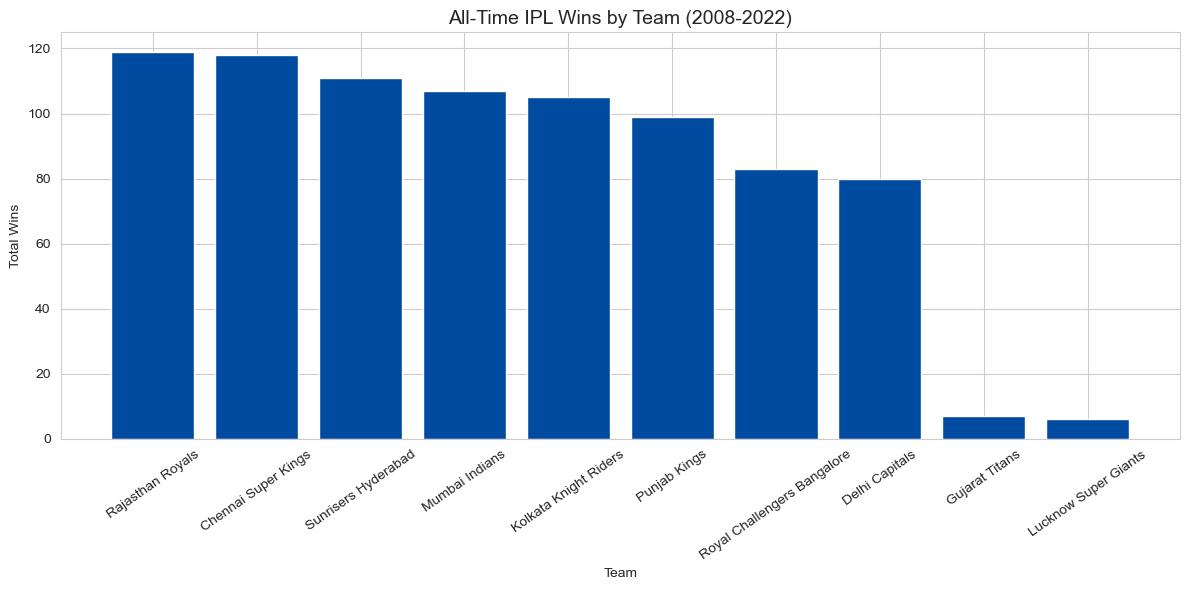

￿ Chart 1 saved


In [5]:
# Count wins for each team
wins = matches_clean['winner'].value_counts()
print("Wins per team:")
print(wins)
# Draw a bar chart
plt.figure(figsize=(12, 6))
plt.bar(wins.index, wins.values, color='#004BA0', edgecolor='white')
plt.title('All-Time IPL Wins by Team (2008-2022)', fontsize=14)
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.xticks(rotation=35) # rotate team names so they don't overlap
plt.tight_layout()
plt.savefig('chart1_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()
print("￿ Chart 1 saved")

Toss win AND match win: 393
Toss win BUT match loss: 442
Winning toss = winning match only 47.1 % of the time


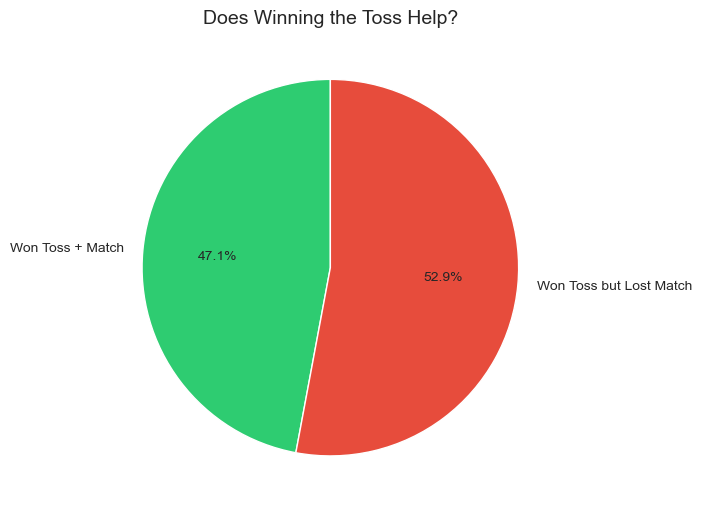

￿ Chart 2 saved


In [6]:
# Find matches where toss winner = match winner
toss_also_won = matches_clean[matches_clean['toss_winner'] == matches_clean['winner']]
toss_but_lost = matches_clean[matches_clean['toss_winner'] != matches_clean['winner']]
# Calculate percentage
toss_win_pct = round(len(toss_also_won) / len(matches_clean) * 100, 1)
print("Toss win AND match win:", len(toss_also_won))
print("Toss win BUT match loss:", len(toss_but_lost))
print("Winning toss = winning match only", toss_win_pct, "% of the time")
# Draw a pie chart
plt.figure(figsize=(7, 7))
sizes = [len(toss_also_won), len(toss_but_lost)]
labels = ['Won Toss + Match', 'Won Toss but Lost Match']
colors = ['#2ECC71', '#E74C3C']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Does Winning the Toss Help?', fontsize=14)
plt.tight_layout()
plt.savefig('chart2_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("￿ Chart 2 saved")

Top 10 run scorers:
batsman
SR Watson         16268
DJ Bravo          16174
MS Dhoni          15964
AB de Villiers    14800
S Dhawan          14716
RR Pant           14562
KA Pollard        14490
DA Warner         14314
CH Gayle          14213
JP Duminy         14190
Name: batsman_runs, dtype: int64


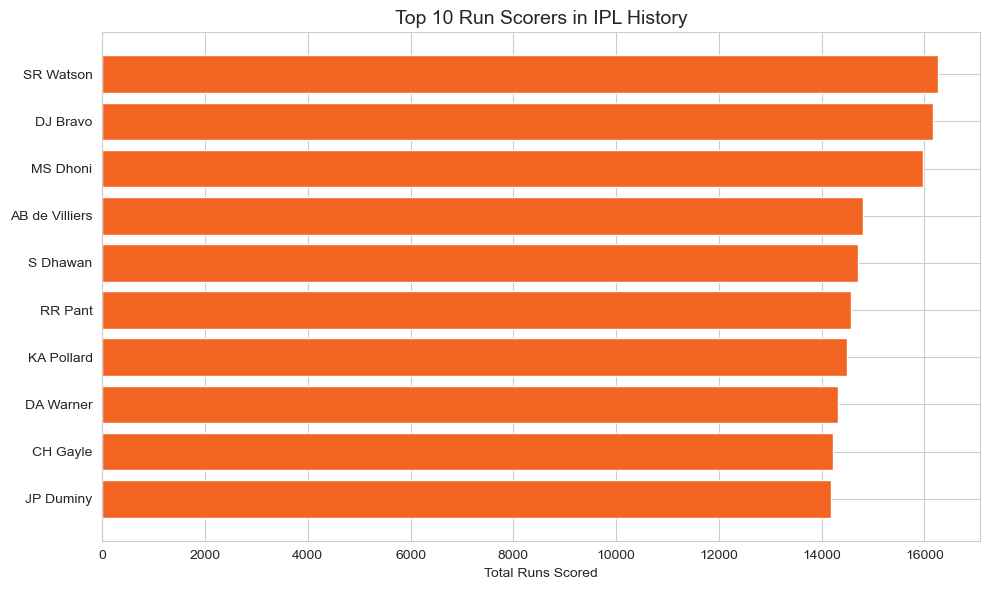

￿ Chart 3 saved


In [7]:
# Add up total runs for each batsman
# groupby groups all rows by the batsman column
# ['batsman_runs'].sum() adds up their runs
# sort_values sorts from highest to lowest
# .head(10) keeps only top 10
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum()
top_batsmen = top_batsmen.sort_values(ascending=False)
top_batsmen = top_batsmen.head(10)
print("Top 10 run scorers:")
print(top_batsmen)
# Draw horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_batsmen.index[::-1], top_batsmen.values[::-1],
color='#F26522', edgecolor='white')
plt.title('Top 10 Run Scorers in IPL History', fontsize=14)
plt.xlabel('Total Runs Scored')
plt.tight_layout()
plt.savefig('chart3_top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()
print("￿ Chart 3 saved")

Top 10 wicket takers:
bowler
MM Sharma         362
DJ Bravo          359
SP Narine         358
SL Malinga        348
JJ Bumrah         348
A Nehra           334
Z Khan            332
UT Yadav          331
Mohammed Shami    331
B Kumar           330
Name: is_wicket, dtype: int64


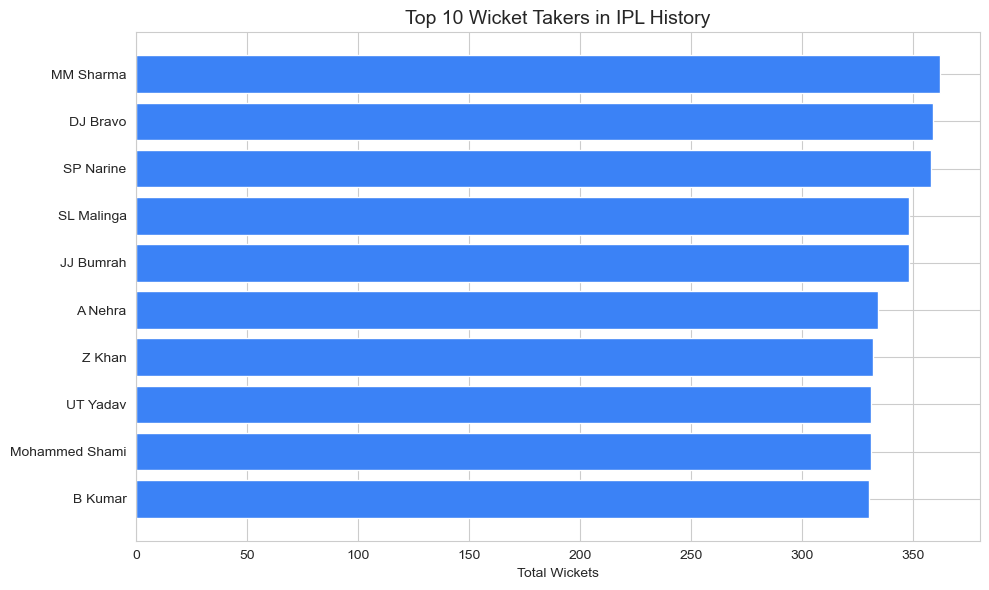

￿ Chart 4 saved


In [8]:
# Filter only rows where a wicket fell
wickets_only = deliveries[deliveries['is_wicket'] == 1].copy()
# Remove run outs — those are not credited to the bowler
wickets_only = wickets_only[wickets_only['dismissal_kind'] != 'run out']
wickets_only = wickets_only[wickets_only['dismissal_kind'] != 'retired hurt']
# Count wickets per bowler
top_bowlers = wickets_only.groupby('bowler')['is_wicket'].count()
top_bowlers = top_bowlers.sort_values(ascending=False)
top_bowlers = top_bowlers.head(10)
print("Top 10 wicket takers:")
print(top_bowlers)
# Draw horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_bowlers.index[::-1], top_bowlers.values[::-1],
color='#3B82F6', edgecolor='white')
plt.title('Top 10 Wicket Takers in IPL History', fontsize=14)
plt.xlabel('Total Wickets')
plt.tight_layout()
plt.savefig('chart4_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
print("￿ Chart 4 saved")

Runs per season:
season
2008    19290
2009    18884
2010    18360
2011    18500
2012    19225
2013    19409
2014    18989
2015    19488
2016    19368
2017    18859
2018    19334
2019    19464
2020    18100
2021    18863
2022    20051
Name: total_runs, dtype: int64


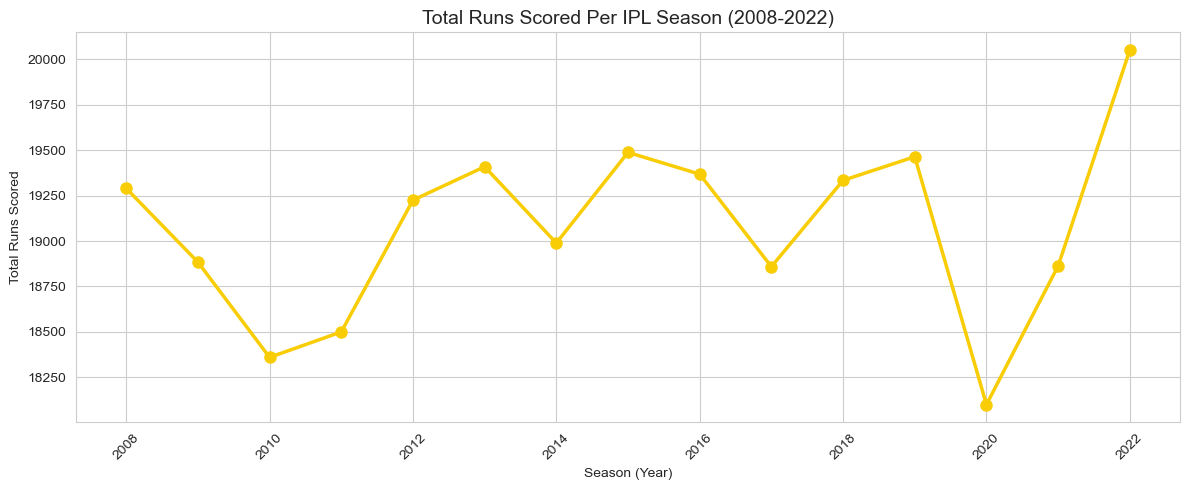

￿ Chart 5 saved


In [9]:
# merge() joins two tables — same as SQL JOIN
# left_on = column name in deliveries table
# right_on = column name in matches table
season_data = deliveries.merge(matches_clean[['id', 'season']],
left_on='match_id',
right_on='id')
# Now group by season and add up all runs
season_runs = season_data.groupby('season')['total_runs'].sum()
print("Runs per season:")
print(season_runs)
# Draw a line chart to show the trend
plt.figure(figsize=(12, 5))
plt.plot(season_runs.index, season_runs.values,
marker='o',
# circle dot at each point
color='#F9CD05',
linewidth=2.5,
markersize=8)
plt.title('Total Runs Scored Per IPL Season (2008-2022)', fontsize=14)
plt.xlabel('Season (Year)')
plt.ylabel('Total Runs Scored')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_season_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print("￿ Chart 5 saved")

Top 10 Player of Match winners:
player_of_match
DJ Bravo           30
Harbhajan Singh    29
Z Khan             28
SS Iyer            28
RG Sharma          27
SP Narine          27
R Ashwin           26
DA Warner          26
V Kohli            26
F du Plessis       25
Name: count, dtype: int64


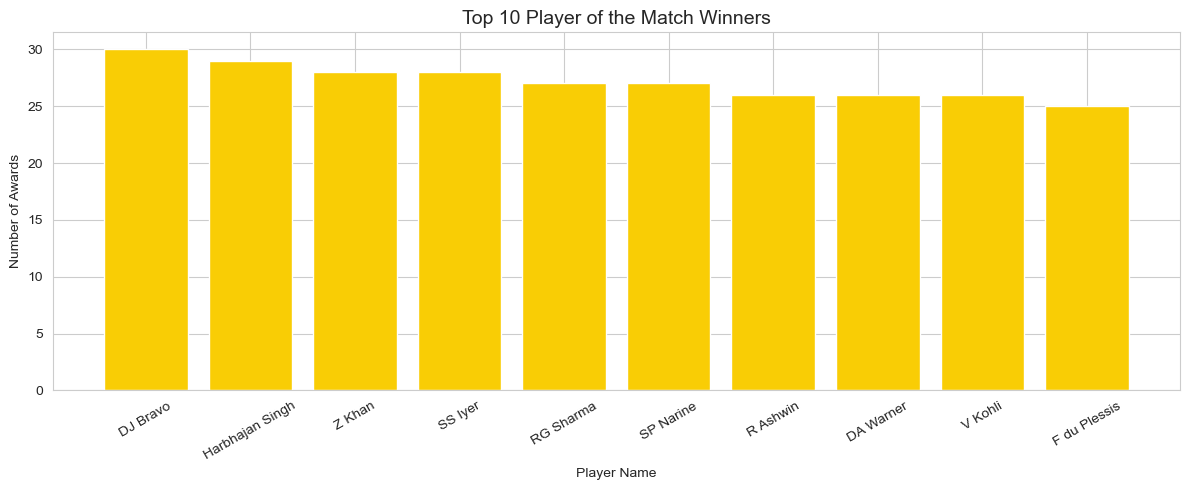

￿ Chart 6 saved


In [10]:
# Count how many times each player won Player of Match award
pom = matches_clean['player_of_match'].value_counts().head(10)
print("Top 10 Player of Match winners:")
print(pom)
# Draw a bar chart
plt.figure(figsize=(12, 5))
plt.bar(pom.index, pom.values, color='#F9CD05', edgecolor='white')
plt.title('Top 10 Player of the Match Winners', fontsize=14)
plt.xlabel('Player Name')
plt.ylabel('Number of Awards')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart6_player_of_match.png', dpi=150, bbox_inches='tight')
plt.show()
print("￿ Chart 6 saved")

## ￿ Key Findings from IPL Analytics (2008–2022)
### Finding 1 — Toss is Overrated
Winning the toss only leads to winning the match ~47% of the time.
It's basically a coin flip. Strategy and team strength matter more.
### Finding 2 — Fielding First is the Modern Strategy
~64% of toss winners choose to field first and chase.
Teams trust their batting lineup to chase targets.
### Finding 3 — Mumbai Indians are the Dominant Force
Mumbai Indians have the most wins across all seasons.
Consistent squad, experienced captain, and strong team culture.
### Finding 4 — Individual Stars Drive Results
Top 3 run scorers account for a disproportionate share of total runs.
Star players have a massive impact in T20 format.
### Finding 5 — IPL Batting is Improving Every Season
Total runs per season show an upward trend from 2008 to 2022.
Better pitches, smaller grounds, and improved batting techniques.